Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

---
# Selekcja cech i redukcja wymiarowości
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from sklearn.decomposition import PCA

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.7.2'

# Redukcja wymiarowości

### Tworzymy przykładowy zbiór danych
- 10 próbek
- 5 cech

In [3]:
X = np.array([
    [2.5, 2.4, 3.1, 5.2, 1.0],
    [0.5, 0.7, 1.5, 1.2, 0.2],
    [2.2, 2.9, 3.0, 5.0, 1.2],
    [1.9, 2.2, 2.8, 4.8, 0.8],
    [3.1, 3.0, 4.0, 6.0, 2.0],
    [2.3, 2.7, 3.2, 5.3, 0.9],
    [2.0, 1.6, 2.5, 4.5, 1.1],
    [1.0, 1.1, 1.2, 2.0, 0.3],
    [1.5, 1.6, 2.0, 3.0, 0.7],
    [1.1, 0.9, 1.5, 2.2, 0.4]
])

In [4]:
# Centrowanie danych (żeby porównać SVD z PCA)
X_centered = X - np.mean(X, axis=0)

## SVD

In [5]:
X_centered.shape

(10, 5)

In [6]:
U, S, VT = np.linalg.svd(X_centered, full_matrices=False)

In [7]:
# Unitarność
assert np.allclose(np.identity(X.shape[1]), VT.T @ VT)
assert np.allclose(np.identity(X.shape[1]),  U.T @ U)

# Równość z macierzą wyjściową
assert np.allclose(X_centered, U @ np.diag(S) @ VT)

### Wartości i wektory własne

In [8]:
S

array([6.72324745, 0.86021593, 0.77884901, 0.50658462, 0.29789005])

In [9]:
VT.T

array([[-0.34471719, -0.28382225,  0.20518113, -0.38732284,  0.78006199],
       [-0.363062  ,  0.22051213, -0.83601013, -0.34586238, -0.0320415 ],
       [-0.39560287, -0.36946925, -0.25681282,  0.7866794 ,  0.14890783],
       [-0.74034071,  0.43277365,  0.43585871,  0.02473933, -0.27206204],
       [-0.21154206, -0.73960718,  0.05533647, -0.33299208, -0.54248072]])

## PCA

In [10]:
cov_matrix = np.cov(X_centered, rowvar=False)
cov_matrix.shape

(5, 5)

In [11]:
# Inna definicja
assert np.allclose(cov_matrix, X_centered.T @ X_centered / (X.shape[0] - 1))

In [12]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [13]:
# Równość z macierzą wyjściową
assert np.allclose(cov_matrix, eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T)

#### Sortowanie malejące

In [14]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

### Wartości i wektory własne

In [15]:
eigenvalues

array([5.0224507 , 0.08221905, 0.06740064, 0.02851422, 0.00985983])

In [16]:
eigenvectors

array([[-0.34471719, -0.28382225, -0.20518113,  0.38732284, -0.78006199],
       [-0.363062  ,  0.22051213,  0.83601013,  0.34586238,  0.0320415 ],
       [-0.39560287, -0.36946925,  0.25681282, -0.7866794 , -0.14890783],
       [-0.74034071,  0.43277365, -0.43585871, -0.02473933,  0.27206204],
       [-0.21154206, -0.73960718, -0.05533647,  0.33299208,  0.54248072]])

### Główne składowe

In [17]:
pc_pca = X_centered @ eigenvectors
pc_pca

array([[-1.63828102,  0.13354792, -0.13835232, -0.03606336, -0.19067858],
       [ 3.43191985, -0.22193625,  0.22759622, -0.30742438,  0.03099464],
       [-1.57107685,  0.13142142,  0.39163025,  0.1708852 ,  0.12833528],
       [-0.90171275,  0.3453916 , -0.07407874, -0.1583284 ,  0.0983017 ],
       [-3.22280574, -0.63034873,  0.06725318,  0.00903693, -0.01337757],
       [-1.77069633,  0.33675717,  0.14111601, -0.12421029, -0.06698639],
       [-0.44102681, -0.05617138, -0.5590901 ,  0.0162097 ,  0.12686856],
       [ 2.61959054,  0.10745645,  0.02814524,  0.27409356, -0.0296497 ],
       [ 1.12426111, -0.08284323,  0.0910167 ,  0.11980015, -0.03373188],
       [ 2.36982801, -0.06327496, -0.17523644,  0.03600089, -0.05007607]])

### *Loadings*

In [18]:
loadings = eigenvectors @ np.sqrt(np.diag(eigenvalues))
loadings

array([[-0.77253966, -0.08138281, -0.05326837,  0.06540393, -0.07745757],
       [-0.8136519 ,  0.06322935,  0.21704189,  0.05840285,  0.00318161],
       [-0.88657865, -0.10594111,  0.0666728 , -0.1328399 , -0.01478605],
       [-1.6591646 ,  0.12409293, -0.11315604, -0.00417752,  0.02701486],
       [-0.4740832 , -0.21207396, -0.01436625,  0.05622956,  0.05386654]])

In [19]:
# Fundamentalne twierdzenie analizy czynnikowej
assert np.allclose(cov_matrix, loadings @ loadings.T)

### Scree plot (wariancja wyjaśniona)

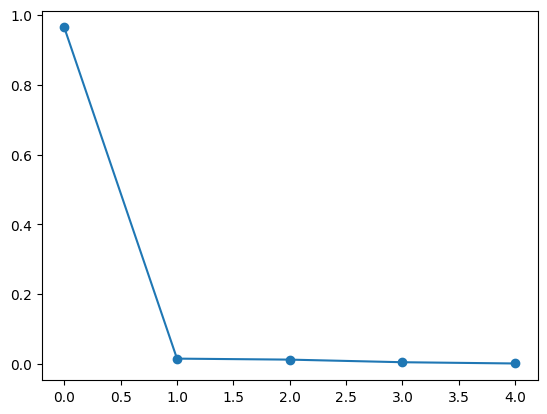

In [20]:
plt.plot(eigenvalues / eigenvalues.sum(), 'o-');

## Porównanie SVD z PCA

In [21]:
# Wartości własne
assert np.allclose(eigenvalues, S ** 2 / (X.shape[0] - 1))

### Projekcja (transformacja) cech

In [22]:
X_trans_svd = X_centered @ VT.T#[:, :2]

In [23]:
X_trans_pca = X_centered @ eigenvectors#[:, :2]

In [24]:
assert np.allclose(X_trans_svd, X_trans_pca, rtol=1e-3, atol=1e-2)

AssertionError: 

#### Co się stało?

## PCA liczone za pomocą `scikit-learn`

In [25]:
pca = PCA()
pca.fit(X_centered)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [26]:
pca.n_components_

5

### Wartości i wektory własne

In [27]:
pca.explained_variance_

array([5.0224507 , 0.08221905, 0.06740064, 0.02851422, 0.00985983])

In [28]:
pca.components_.T  # musimy użyć transpozycji, bo domyślnie wektor to wiersz

array([[ 0.34471719,  0.28382225, -0.20518113, -0.38732284,  0.78006199],
       [ 0.363062  , -0.22051213,  0.83601013, -0.34586238, -0.0320415 ],
       [ 0.39560287,  0.36946925,  0.25681282,  0.7866794 ,  0.14890783],
       [ 0.74034071, -0.43277365, -0.43585871,  0.02473933, -0.27206204],
       [ 0.21154206,  0.73960718, -0.05533647, -0.33299208, -0.54248072]])

### Projekcja (transformacja) cech

In [29]:
assert np.allclose(abs(X_trans_pca), abs(pca.transform(X_centered)))